In [1]:
from sklearn.model_selection import GridSearchCV 
from sklearn.ensemble import RandomForestClassifier # 隨機森林分類器：預測存活與否(0/1)
from sklearn.ensemble import RandomForestRegressor # 隨機森林迴歸模型：預測缺失的年齡數值

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# 關閉 pandas 的 SettingWithCopyWarning 提醒，避免輸出畫面出現大量非必要警告


## 讀取資料
讀入訓練集（train.csv）、測試集（test.csv），
以及 Kaggle 提供的提交範例格式（gender_submission.csv）。

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submit = pd.read_csv("gender_submission.csv")

train.head(5) # 測試，確認資料讀取成功

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 檢查資料狀況

使用 `.info()` 觀察欄位型態與是否有缺失值，
使用 `.describe()` 觀察數值欄位的統計分布。

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Combine Train and Test Data (合併訓練集與測試集)

因為特徵工程（補缺失值、類別轉換、擷取稱謂等）需要同時套用在 train 和 test 上，先合併成一份資料一起處理。
最後再依照 Survived 欄位是否為空，重新拆分回訓練集與測試集。

In [7]:
data = pd.concat([train, test]) #Combine
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [8]:
#由於合併後造成index重複問題，因此要將index重新設定
data.reset_index(inplace=True, drop=True)
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## 資料探索：生存與死亡比例
觀察整體存活狀況，死亡比例約 6 成、存活比例約 4 成。

<Axes: xlabel='Survived', ylabel='count'>

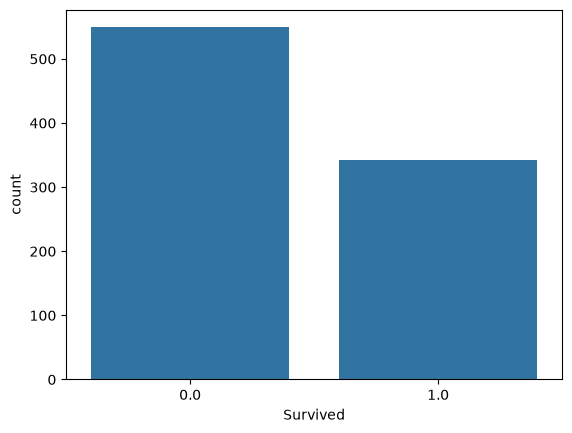

In [9]:
sns.countplot(data=data, x='Survived')

## 資料探索：艙等（Pclass）與生存率的關係
頭等艙（1）生存率最高  
二等艙（2）次之，三等艙（3）生存率最低 → 顯示艙等與生存機率有明顯關聯。

<Axes: xlabel='Pclass', ylabel='count'>

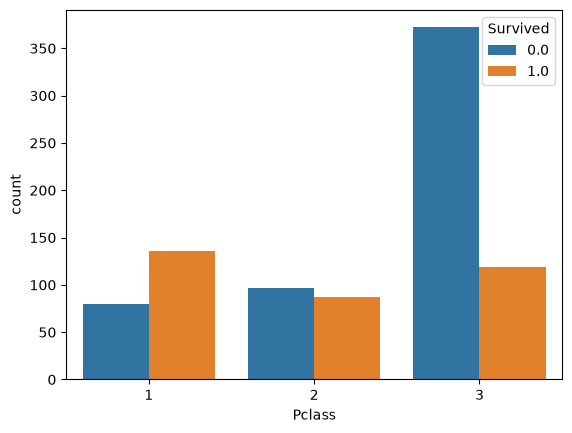

In [10]:
sns.countplot(data=data, x='Pclass', hue='Survived')

## 資料探索：性別 (Sex) 與生存率的關係
女性的生存率明顯高於男性

推測與船難逃生時「婦孺優先」的常見做法有關。

<Axes: xlabel='Sex', ylabel='count'>

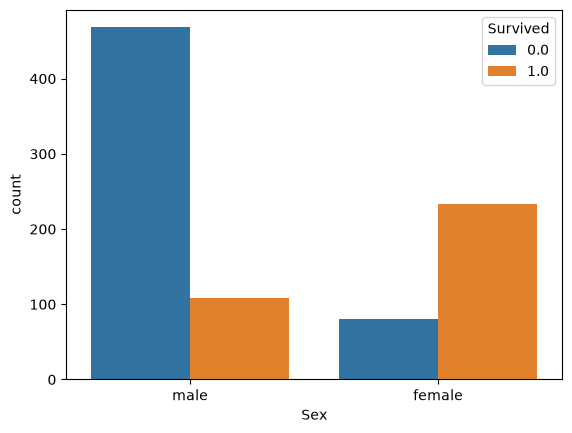

In [11]:
sns.countplot(data=data, x='Sex', hue='Survived')

## 資料探索：出發港口（Embarked）與生存率的關係
S 港出發的乘客死亡比例明顯較高  
推測可能與該港口乘客的票價、艙等分布較低有關，需進一步交叉分析驗證。

<Axes: xlabel='Embarked', ylabel='count'>

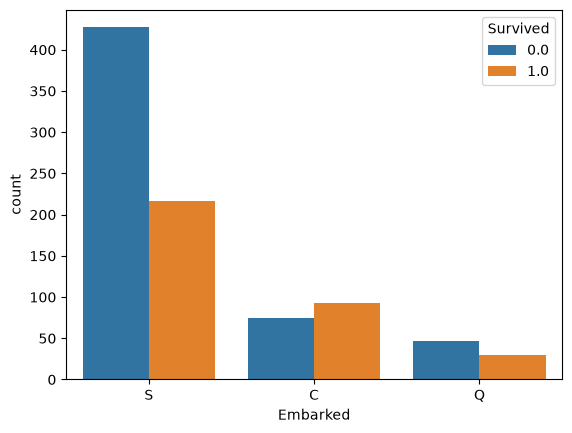

In [12]:
sns.countplot(data=data, x='Embarked', hue="Survived")

## 資料探索：年齡（Age）與生存率的關係
可以發現年齡較小的乘客，存活比例明顯高出許多。

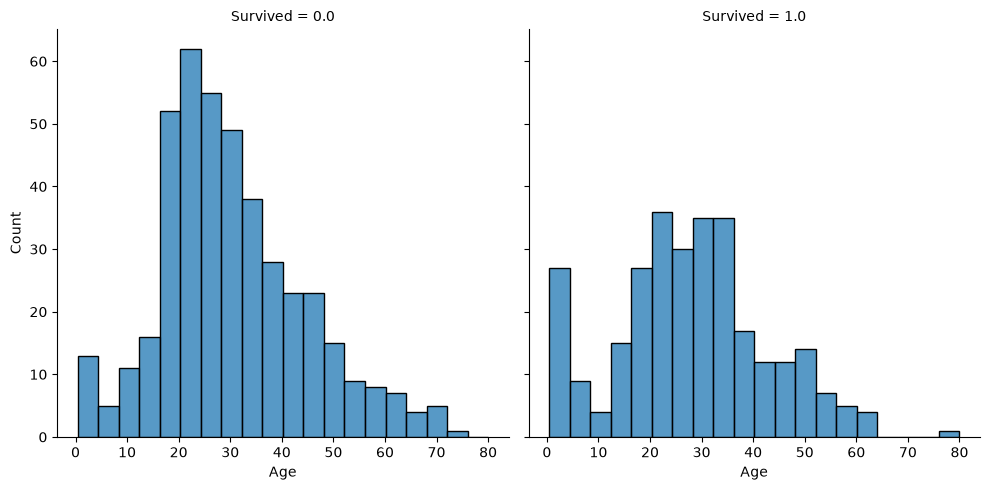

In [13]:
sns.displot(data=data, x='Age', col='Survived', kde=False)

## 資料探索：票價（Fare）與生存率的關係

可以發現票價較低的乘客，死亡比例明顯較高，推測與艙等、社經地位有關。

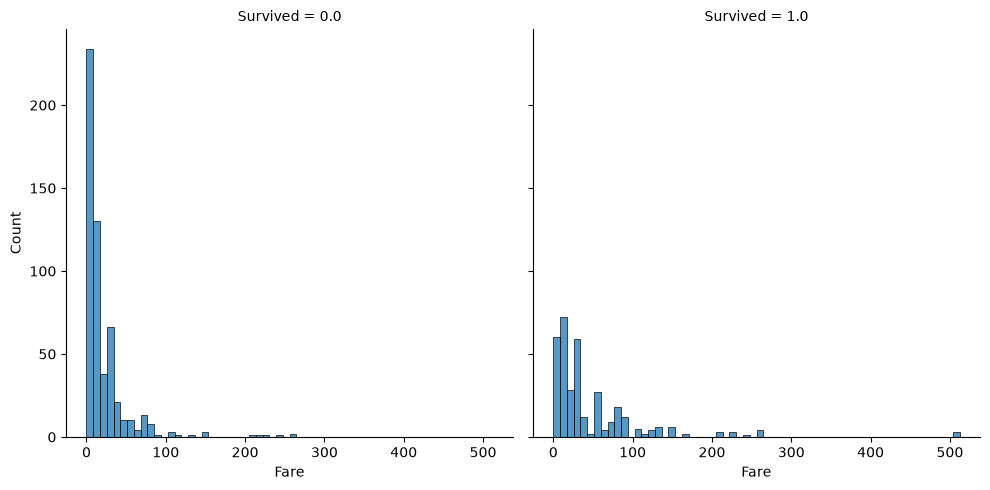

In [14]:
sns.displot(data=data, x='Fare', col='Survived', kde=False)

## 資料探索：家庭人數與生存率的關係

分別觀察父母子女數（Parch）與兄弟姊妹配偶數（SibSp）與生存率的關係，
發現獨自登船的乘客，生存率都低於有家人同行的乘客。

進一步將兩者合併為「家庭大小」（Family_Size = Parch + SibSp）
這個新特徵，測試後發現比起分開使用兩個欄位，能讓後續模型預測更準確。

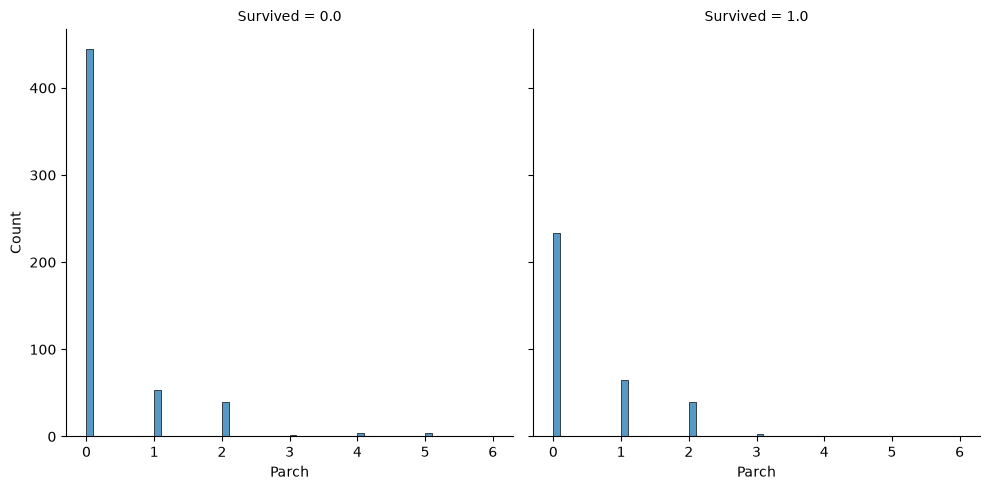

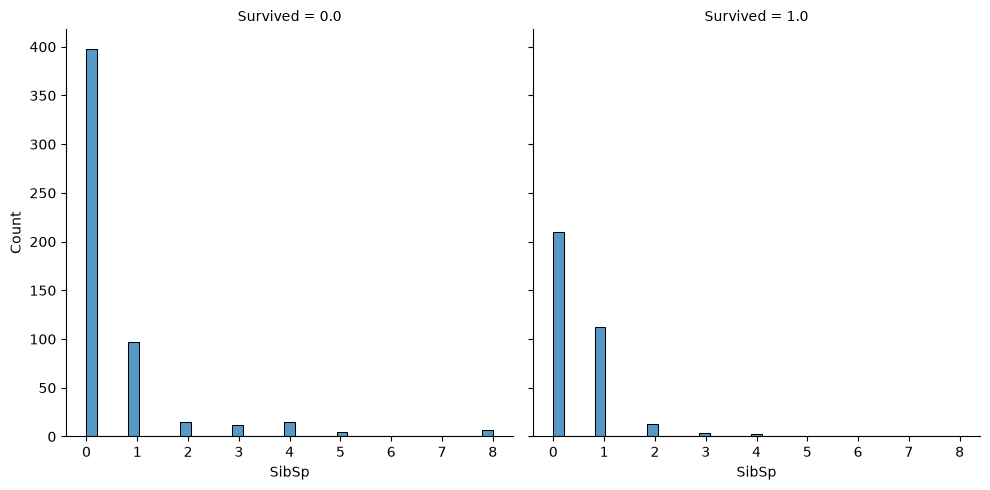

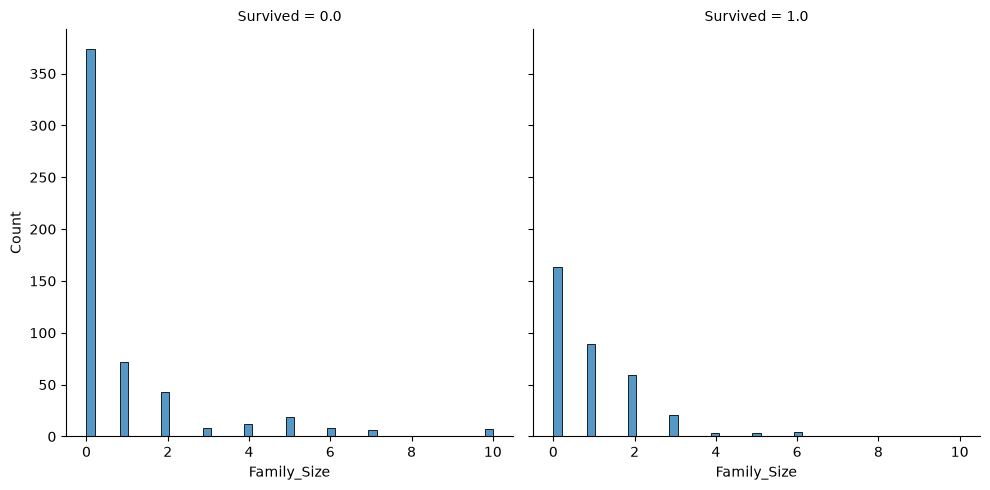

In [15]:
sns.displot(data=data, x='Parch', col='Survived', kde=False)
sns.displot(data=data, x='SibSp', col='Survived', kde=False)

data['Family_Size'] = data['Parch'] + data['SibSp']
sns.displot(data=data, x='Family_Size', col='Survived', kde=False)

## 從姓名擷取稱謂（Title）

姓名欄位本身無法直接用於模型訓練，但其中包含的稱謂資訊
（例如 Mr、Miss、Mrs）與年齡、性別、社經地位有關，
因此先將稱謂從姓名中擷取出來，作為一個新的特徵。

In [16]:
data['Title1'] = data['Name'].str.split(", ", expand=True)[1]
data['Title1'] = data['Title1'].str.split(".", expand=True)[0]
data['Title1'].unique()

<StringArray>
[          'Mr',          'Mrs',         'Miss',       'Master',
          'Don',          'Rev',           'Dr',          'Mme',
           'Ms',        'Major',         'Lady',          'Sir',
         'Mlle',          'Col',         'Capt', 'the Countess',
     'Jonkheer',         'Dona']
Length: 18, dtype: str

## 資料探索：稱謂（Title1）與性別、生存率、年齡的關係

從姓名中擷取稱謂後，依序檢視稱謂與性別、生存率、年齡的關係：

- 稱謂與性別高度對應（例如 Master 全為男性），驗證這個新特徵合理
- 稱謂與生存率有明顯差異，顯示稱謂可能反映乘客的身分地位
- 稱謂與平均年齡有清楚規律（例如 Master 平均年齡僅約 5 歲），
  進一步交叉艙等後發現同一稱謂在不同艙等間仍有年齡差異
  
這顯示稱謂間接反映了乘客的年齡層與身分，
可作為後續補齊缺失年齡值的重要依據。

In [17]:
# 稱謂 vs 性別
pd.crosstab(data['Title1'], data['Sex']).T.style.background_gradient(cmap='Blues')

Title1,Capt,Col,Don,Dona,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess
Sex,,,,,,,,,,,,,,,,,,
female,0,0,0,1,1,0,1,0,0,260,2,1,0,197,2,0,0,1
male,1,4,1,0,7,1,0,2,61,0,0,0,757,0,0,8,1,0


In [18]:
# 稱謂(可能間接代表身分地位) vs 生存率
pd.crosstab(data['Title1'],data['Survived']).T.style.background_gradient(cmap='Blues')

Title1,Capt,Col,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess
Survived,,,,,,,,,,,,,,,,,
0.000000,1,1,1,4,1,0,1,17,55,0,0,436,26,0,6,0,0
1.000000,0,1,0,3,0,1,1,23,127,2,1,81,99,1,0,1,1


In [19]:
# 稱謂 vs 平均年齡
data.groupby(['Title1'])['Age'].mean()

Title1
Capt            70.000000
Col             54.000000
Don             40.000000
Dona            39.000000
Dr              43.571429
Jonkheer        38.000000
Lady            48.000000
Major           48.500000
Master           5.482642
Miss            21.774238
Mlle            24.000000
Mme             24.000000
Mr              32.252151
Mrs             36.994118
Ms              28.000000
Rev             41.250000
Sir             49.000000
the Countess    33.000000
Name: Age, dtype: float64

In [20]:
# 稱謂+艙等 vs 平均年齡
data.groupby(['Title1', 'Pclass'])['Age'].mean()

Title1        Pclass
Capt          1         70.000000
Col           1         54.000000
Don           1         40.000000
Dona          1         39.000000
Dr            1         45.600000
              2         38.500000
Jonkheer      1         38.000000
Lady          1         48.000000
Major         1         48.500000
Master        1          6.984000
              2          2.757273
              3          6.090000
Miss          1         30.338983
              2         20.717083
              3         17.360874
Mlle          1         24.000000
Mme           1         24.000000
Mr            1         41.450758
              2         32.346715
              3         28.318910
Mrs           1         43.208955
              2         33.518519
              3         32.326531
Ms            2         28.000000
              3               NaN
Rev           2         41.250000
Sir           1         49.000000
the Countess  1         33.000000
Name: Age, dtype: float64

## 合併稀少的稱謂類別

觀察發現部分稱謂（如 Capt、Don、Jonkheer 等）人數極少（多數僅 1-2 人），  
若保留這些稀有類別，模型難以從中學到有效規律。  
因此依照性別與身分相近原則，將這些稱謂合併為 Mr、Mrs、Miss、Master 四大類，  
確保每個類別都有足夠樣本數，避免稀有類別對模型訓練造成干擾。

合併後再次檢視稱謂與性別、生存率的關係，確認規律依然一致，顯示合併並未造成資訊流失。

In [21]:
data['Title2'] = data['Title1'].replace(
    ['Mlle','Mme','Ms','Dr','Major','Lady','the Countess','Jonkheer','Col','Rev','Capt','Sir','Don','Dona'],
    ['Miss','Mrs','Miss','Mr','Mr','Mrs','Mrs','Mr','Mr','Mr','Mr','Mr','Mr','Mrs']
)
data['Title2'].unique()

<StringArray>
['Mr', 'Mrs', 'Miss', 'Master']
Length: 4, dtype: str

In [22]:
data.groupby('Title2')['Age'].mean()

Title2
Master     5.482642
Miss      21.824366
Mr        32.811056
Mrs       36.971264
Name: Age, dtype: float64

In [23]:
pd.crosstab(data['Title2'], data['Sex']).T.style.background_gradient(cmap='Blues')

Title2,Master,Miss,Mr,Mrs
Sex,,,,
female,0,264,1,201
male,61,0,782,0


In [24]:
pd.crosstab(data['Title2'],data['Survived']).T.style.background_gradient(cmap='Blues')

Title2,Master,Miss,Mr,Mrs
Survived,,,,
0.000000,17,55,451,26
1.000000,23,130,87,102


## 確認目前資料狀態

完成稱謂、家庭人數等特徵新增後，再次檢查資料的欄位與缺失值狀況，  
確認後續還需要處理 Age、Cabin、Embarked 等欄位的缺失值

In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  Family_Size  1309 non-null   int64  
 13  Title1       1309 non-null   str    
 14  Title2       1309 non-null   str    
dtypes: float64(3), int64(5), str(7)
memory usage: 153.5 KB


## 資料探索：票號代碼與生存率的關係

從票號擷取代碼後共有 36 種類別，但除了純數字票（'X'）外，  
多數代碼樣本數極少，多僅個位筆數，呈現長尾分布，可能為模型帶來雜訊。  
後續特徵重要性分析也顯示 Ticket_info 的貢獻度偏低，

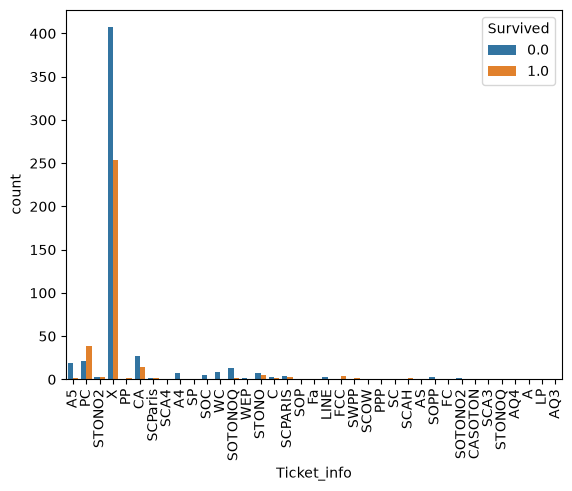

In [26]:
data['Ticket_info'] = data['Ticket'].apply(
    lambda x: 
    x.replace(".", "")
    .replace("/", "")
    .strip()
    .split(' ')[0] 
    #檢查Ticket是不是純數字
    if not x.isdigit() else 'X'
)
data['Ticket_info'].unique()

sns.countplot(data=data, x='Ticket_info', hue='Survived')
plt.xticks(rotation=90)
plt.show()

## 補齊缺失值：Embarked、Fare

Embarked 缺失的 2 筆資料，依照多數乘客的上船港口，補為 'S'；
Fare 缺失的 1 筆資料，以全體票價的平均值補齊。

In [27]:
data['Embarked'] = data['Embarked'].fillna('S')
data['Fare'] = data['Fare'].fillna(data['Fare'].mean())
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1309 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1309 non-null   str    
 12  Family_Size  1309 non-null   int64  
 13  Title1       1309 non-null   str    
 14  Title2       1309 non-null   str    
 15  Ticket_info  1309 non-null   str    
dtypes: float64(3), int64(5), str(8)
memory usage: 163.8 KB


## 處理 Cabin 欄位

Cabin 缺失比例極高（1309 筆中僅 295 筆有值），直接補值意義不大。  
觀察後發現 Cabin 開頭字母（例如 C85 的 C）代表艙房區域，
因此取字首作為新特徵，缺失則標記為 'NoCabin'，
藉此保留「有無艙房資訊」這個線索，而非直接捨棄整個欄位。

In [28]:
data['Cabin'].head(10)

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: str

In [29]:
data["Cabin"] = data['Cabin'].apply(
    lambda x : str(x)[0] 
    if not pd.isnull(x) else 'NoCabin'
    )

data["Cabin"].unique()

<StringArray>
['NoCabin', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

<Axes: xlabel='Cabin', ylabel='count'>

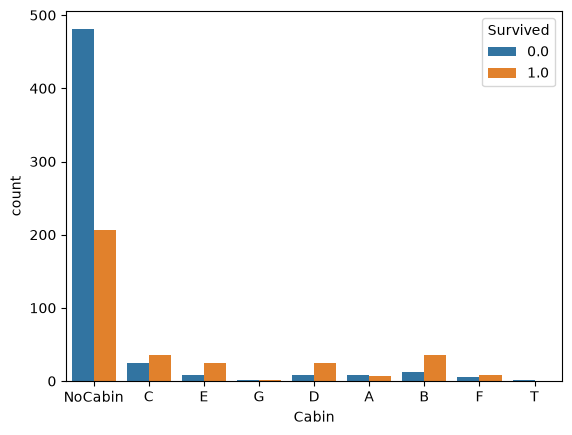

In [30]:
sns.countplot(data=data, x='Cabin', hue='Survived')

## 將類別型欄位轉換為整數

模型無法直接處理文字，將 Sex、Embarked、Pclass、Title1、Title2、Cabin、Ticket_info 這些類別型欄位，轉換為對應的整數編碼。

In [31]:
data['Sex'] = data['Sex'].astype('category').cat.codes
data['Embarked'] = data['Embarked'].astype('category').cat.codes
data['Pclass'] = data['Pclass'].astype('category').cat.codes
data['Title1'] = data['Title1'].astype('category').cat.codes
data['Title2'] = data['Title2'].astype('category').cat.codes
data['Cabin'] = data['Cabin'].astype('category').cat.codes
data['Ticket_info'] = data['Ticket_info'].astype('category').cat.codes
# .astype('category')：告訴 pandas「這欄是有限的幾種類別，不是自由文字」
# .cat.codes：把每種類別自動換成一個整數編號

## 使用隨機森林預測缺失的年齡

Age 欄位缺失比例較高，直接用平均值或中位數填補可能過於粗略。  
利用其他已知特徵（艙等、性別、家庭大小、稱謂等）與已知年齡的乘客
訓練一個隨機森林迴歸模型，用來預測缺失的年齡值，
使補值更貼近乘客的實際特徵。

**修正說明**：原文章此處篩選離群值時未使用反轉條件（`~`），
導致 `remove_outlier` 變數實際上存的是離群值本身（26 筆），
而非移除離群值後的乾淨資料。  
此處加上 `~` 反轉條件後修正，確保訓練資料為排除離群值後的 1020 筆乾淨資料。

In [32]:
dataAgeNull = data[data["Age"].isnull()]
dataAgeNotNull = data[data["Age"].notnull()]

#從「Age 已知」的資料裡,篩選出「Fare 或 Family_Size 極端異常的乘客」
outlier_condition = (
    (np.abs(dataAgeNotNull["Fare"] - dataAgeNotNull["Fare"].mean()) > (4 * dataAgeNotNull["Fare"].std())) |
    (np.abs(dataAgeNotNull["Family_Size"] - dataAgeNotNull["Family_Size"].mean()) > (4 * dataAgeNotNull["Family_Size"].std()))
)

# 用 ~ 反轉條件，取得「排除離群值後」的乾淨資料
clean_data = dataAgeNotNull[~outlier_condition]

# 建立一個隨機森林迴歸模型
rfModel_age = RandomForestRegressor(n_estimators=2000, random_state=42)
# 用哪些特徵來預測年齡
ageColumns = ['Embarked', 'Fare', 'Pclass', 'Sex', 'Family_Size', 'Title1', 'Title2', 'Cabin', 'Ticket_info']
# 開始訓練模型，.fit(特徵, 答案)
rfModel_age.fit(clean_data[ageColumns], clean_data["Age"])

print(len(clean_data)) #1020

# 對「Age缺失」的乘客,逐一預測出他們的年齡
ageNullValues = rfModel_age.predict(X=dataAgeNull[ageColumns])
# 把預測出來的年齡,填回這些乘客的 Age 欄位
dataAgeNull.loc[:, "Age"] = ageNullValues
# 重新合併
data = pd.concat([dataAgeNull, dataAgeNotNull])
# 整理索引
data.reset_index(inplace=True, drop=True)

1020


## 拆分回訓練集與測試集

補齊年齡後，依照 Survived 欄位是否為空，
將合併的資料重新拆分回訓練集與測試集，並確認目前可用的欄位。

In [33]:
dataTrain = data[pd.notnull(data['Survived'])].sort_values(by=["PassengerId"])
dataTest = data[~pd.notnull(data['Survived'])].sort_values(by=["PassengerId"])

dataTrain.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size', 'Title1',
       'Title2', 'Ticket_info'],
      dtype='str')

## 篩選最終訓練用欄位

保留 Survived（答案）與經過處理的特徵欄位，
移除已轉換的原始文字欄位（如 Name、Ticket、Title1）
與無關的 PassengerId，作為模型訓練的最終資料。

In [34]:
dataTrain = dataTrain[['Survived', 'Age', 'Embarked', 'Fare', 'Pclass', 'Sex', 'Family_Size', 'Title2', 'Ticket_info', 'Cabin']]
dataTest = dataTest[['Age', 'Embarked', 'Fare', 'Pclass', 'Sex', 'Family_Size', 'Title2', 'Ticket_info', 'Cabin']]

dataTrain

,Survived,Age,Embarked,Fare,Pclass,Sex,Family_Size,Title2,Ticket_info,Cabin
263,0.0,22.000000,2,7.2500,2,1,1,2,2,7
264,1.0,38.000000,0,71.2833,0,0,1,3,14,2
265,1.0,26.000000,2,7.9250,2,0,0,1,31,7
266,1.0,35.000000,2,53.1000,0,0,1,3,36,2
267,0.0,35.000000,2,8.0500,2,1,0,2,36,7
...,...,...,...,...,...,...,...,...,...,...
973,0.0,27.000000,2,13.0000,1,1,0,2,36,7
974,1.0,19.000000,2,30.0000,0,0,0,1,36,1
176,0.0,10.335519,2,23.4500,2,0,3,1,34,7
975,1.0,26.000000,0,30.0000,0,1,0,2,36,2


## 訓練隨機森林模型

使用 GridSearchCV 找出的最佳參數，訓練隨機森林分類模型，
並利用 oob_score（袋外評分）估算模型準確率。

**與原文章的差異**：修正了年齡預測模型中離群值篩選的邏輯錯誤後
（原文章誤用了離群值本身訓練，而非排除離群值後的乾淨資料），
最終 OOB 準確率由原文章的 0.8294 提升至 0.8361，
驗證了修正後年齡補值更準確，進而提升了整體模型表現。

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    criterion='gini',
    n_estimators=1000,
    min_samples_split=12,
    min_samples_leaf=1,
    oob_score=True, #Out-of-Bag Score
    random_state=1,
    n_jobs=-1
)

rf.fit(
    dataTrain.iloc[:, 1:], # 剩下所有的特徵欄位(Age, Embarked...)
    dataTrain.iloc[:, 0])  # Survived 這個答案欄位

print("%.4f" % rf.oob_score_)

0.8361


## 檢視特徵重要性

整理各特徵對模型預測的貢獻程度，由高到低排序，
確認哪些特徵對存活率預測影響最大。

In [36]:
pd.concat(
    (
        # 取出除了第一欄(Survived)以外,所有欄位的名稱，做成表格
        pd.DataFrame(dataTrain.iloc[:, 1:].columns, columns = ['variable']), 
        #建立「重要性分數」的表格
        pd.DataFrame(rf.feature_importances_, columns = ['importance'])
    ), 
    axis = 1 # 表格「左右合併」
    ).sort_values(by='importance', ascending = False)[:20] # 依重要性由高到低排序

,variable,importance
4,Sex,0.265847
2,Fare,0.159652
6,Title2,0.147300
0,Age,0.144916
3,Pclass,0.089379
5,Family_Size,0.071337
8,Cabin,0.066147
7,Ticket_info,0.031497
1,Embarked,0.023924


## 產生提交檔案

使用訓練好的模型對測試集進行預測，
產生符合 Kaggle 提交格式的 submit.csv。

In [37]:
# 使用訓練好的模型，對測試集進行預測
rf_res = rf.predict(dataTest)

# 將預測結果寫入提交表格，並確保格式符合 Kaggle 規範（整數 0/1）
submit['Survived'] = rf_res
submit['Survived'] = submit['Survived'].astype(int)

# 輸出為符合 Kaggle 格式的提交檔案
submit.to_csv('submit.csv', index=False)

submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
